In [1]:
import sys
print(sys.executable)

d:\anaconda3\envs\dl\python.exe


In [2]:
%load_ext autoreload
%autoreload 2

# 1. 导包+全局变量

In [3]:
import GetData
import Model
import Train

import torch 
from torch.utils.data import TensorDataset,DataLoader
import numpy as np

import matplotlib.pyplot as plt


In [4]:
EPOCHS=15
PRINT_EPOC=1
BATCH_SIZE=128  # 原论文128
lr=2e-4
wd=0

device="cuda:0" if torch.cuda.is_available() else "cpu"
IN_CHANNELS=1
HIDDEN_CHANNELS=128
OUT_CHANNELS=1
RESIDUAL_CHANNELS=32
RESIDUAL_LAYERS=2
NUM_EMBEDDINGS=15
EMBEDDING_DIM=64
DECAY=0.99
COMMIT_COST=0.25

mean=[0.0]
std=[1.0]

# 2. 准备数据

## 2.1 获取加载器+标签字典

In [5]:
train_loader,test_loader=GetData.get_MNIST(BATCH_SIZE)

## 2.2 可视化

torch.Size([128, 1, 32, 32])


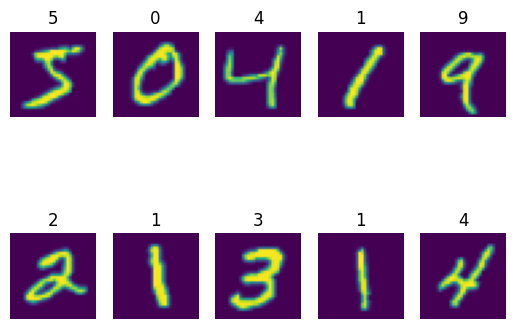

In [7]:
first_train_batch=next(iter(train_loader))
first_test_batch=next(iter(train_loader))

first_train_batch_image=first_train_batch[0][:10].permute(0,2,3,1)
first_train_batch_label=first_train_batch[1][:10]
print(first_train_batch[0].shape)
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(first_train_batch_image[i])
    plt.title(first_train_batch_label[i].item())
    plt.axis("off")
plt.show()

# 3. 训练

In [8]:
init_model=Model.Model(
    IN_CHANNELS,HIDDEN_CHANNELS,OUT_CHANNELS,
    RESIDUAL_CHANNELS,RESIDUAL_LAYERS,
    NUM_EMBEDDINGS,EMBEDDING_DIM,DECAY,COMMIT_COST
)

epoch: 1
reconstruction loss=0.06068834467728933
commit loss=0.08004667160823786
total loss=0.14073501594861348
perplexity=1.0



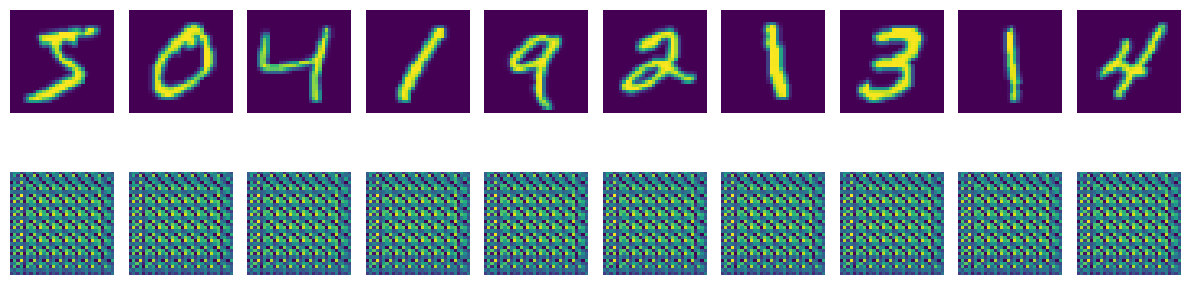

epoch: 2
reconstruction loss=0.036958119210600854
commit loss=0.0512203109793365
total loss=0.08817843016485373
perplexity=2.0098318181355794



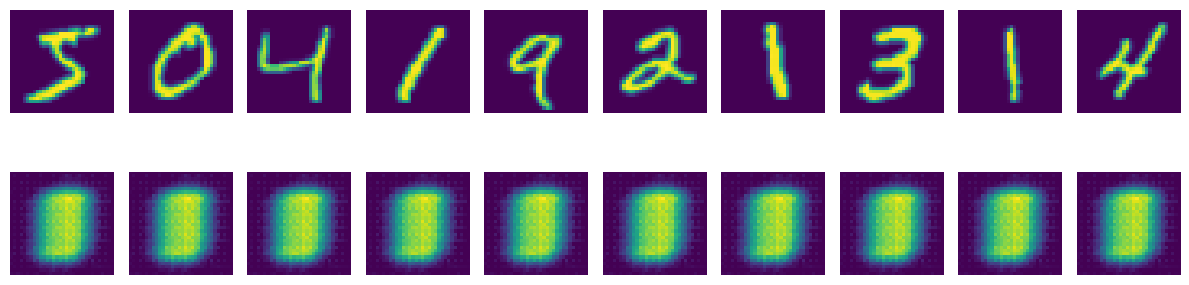

epoch: 3
reconstruction loss=0.006269877665738265
commit loss=0.0019820335986713566
total loss=0.008251911256213983
perplexity=4.850920697021484



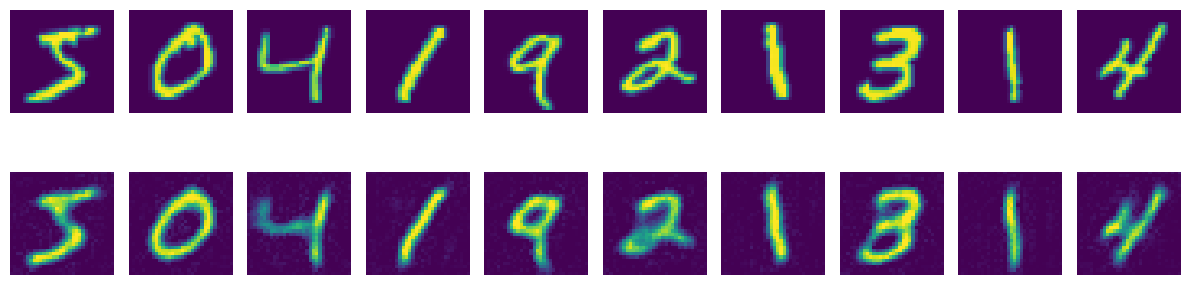

epoch: 4
reconstruction loss=0.004482313399513563
commit loss=0.0016630521298075715
total loss=0.0061453655270238714
perplexity=5.39584695409139



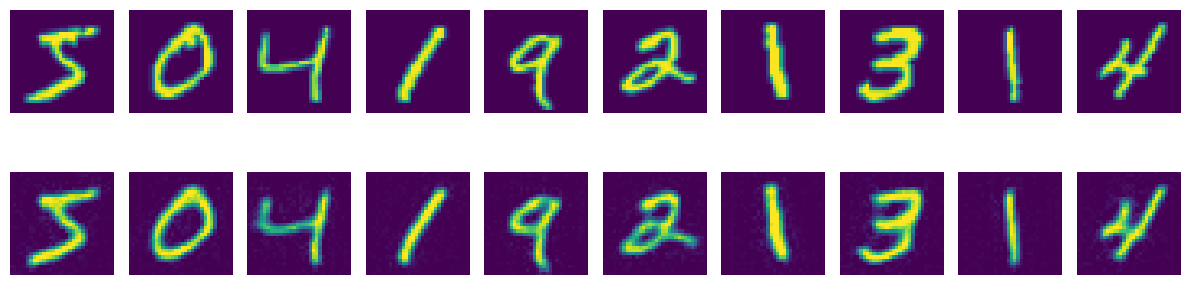

epoch: 5
reconstruction loss=0.0037925468227515617
commit loss=0.0014966338130335012
total loss=0.0052891806369026505
perplexity=5.700821375528971



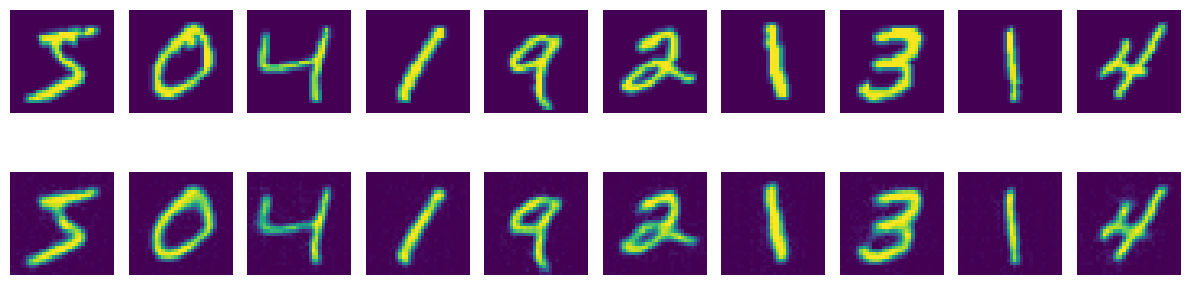

epoch: 6
reconstruction loss=0.003168665667871634
commit loss=0.0012837982200086116
total loss=0.004452463875214259
perplexity=6.529218980407715



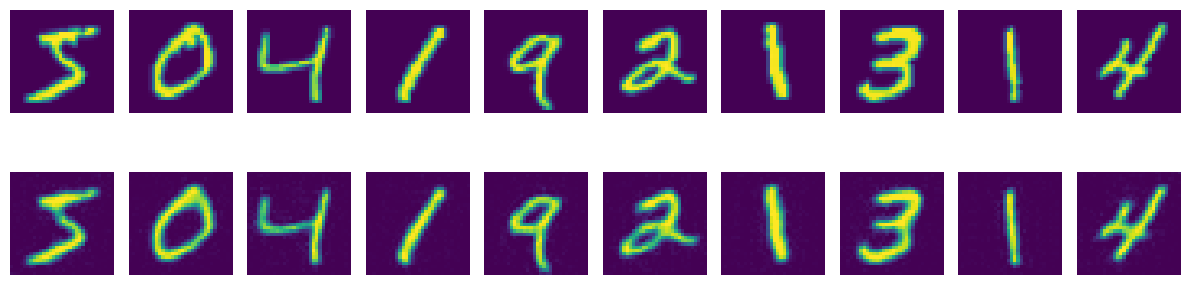

epoch: 7
reconstruction loss=0.0028130994893610477
commit loss=0.0011490494805077712
total loss=0.003962148972352346
perplexity=6.974243584442139



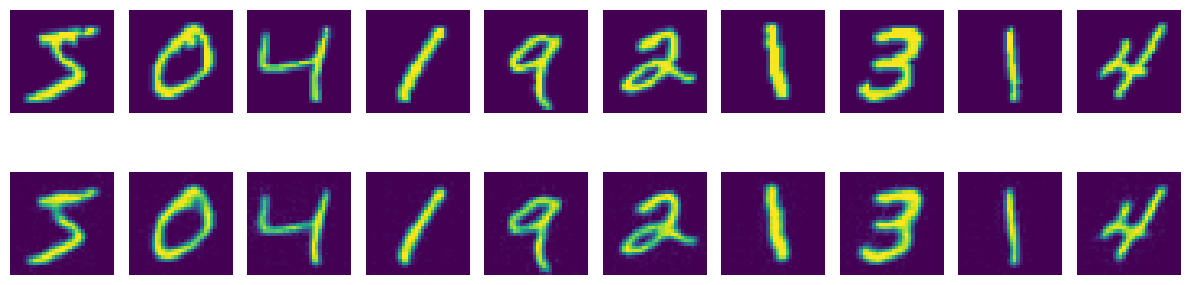

epoch: 8
reconstruction loss=0.0026428145649532477
commit loss=0.0011533430427933733
total loss=0.003796157612154881
perplexity=7.063367317708333



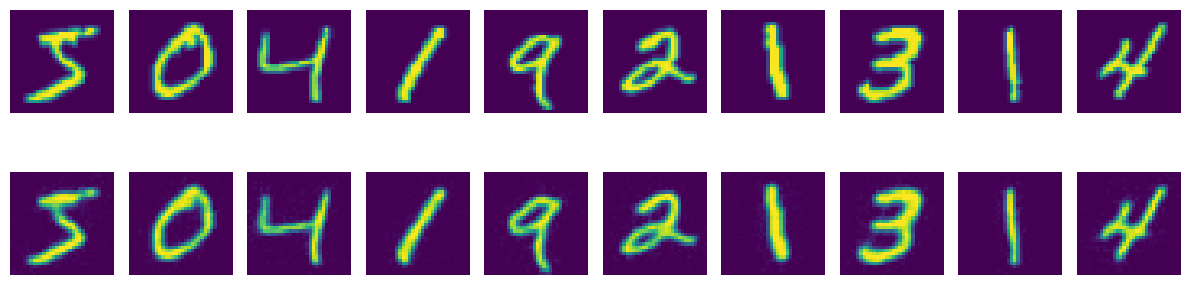

epoch: 9
reconstruction loss=0.002505209042131901
commit loss=0.0011643542315190037
total loss=0.003669563273340464
perplexity=7.135236451975505



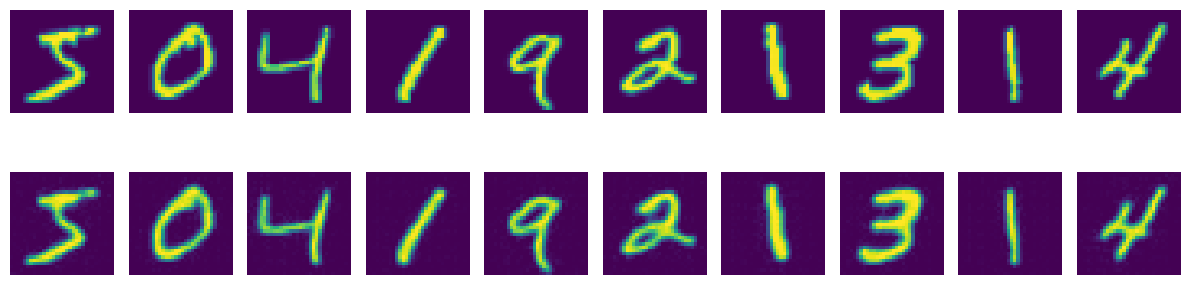

epoch: 10
reconstruction loss=0.002397451762109995
commit loss=0.001178287835419178
total loss=0.003575739599019289
perplexity=7.21634262415568



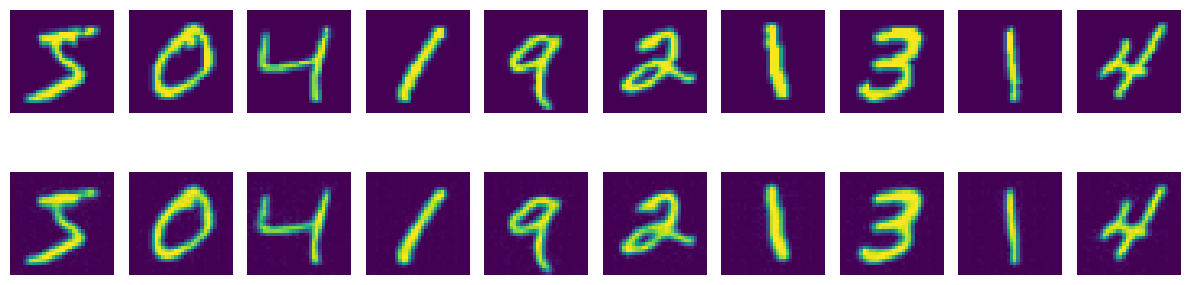

epoch: 11
reconstruction loss=0.002309307083984216
commit loss=0.0012063369331260522
total loss=0.0035156440178553262
perplexity=7.273326635233561



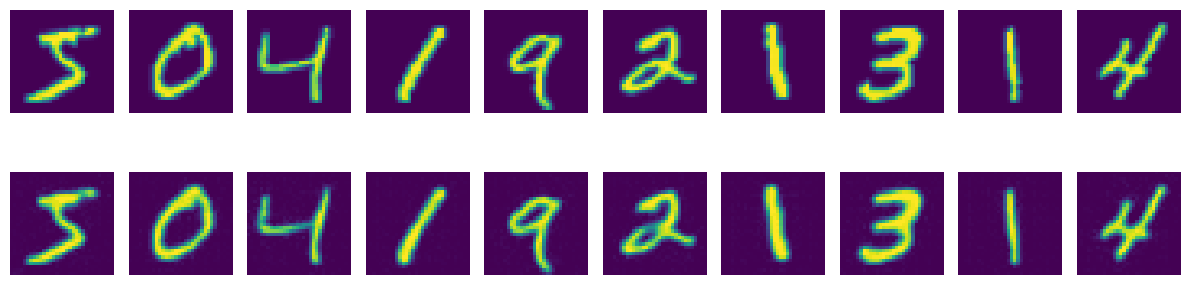

epoch: 12
reconstruction loss=0.00223919764769574
commit loss=0.00124178239920487
total loss=0.003480980050067107
perplexity=7.321609878794352



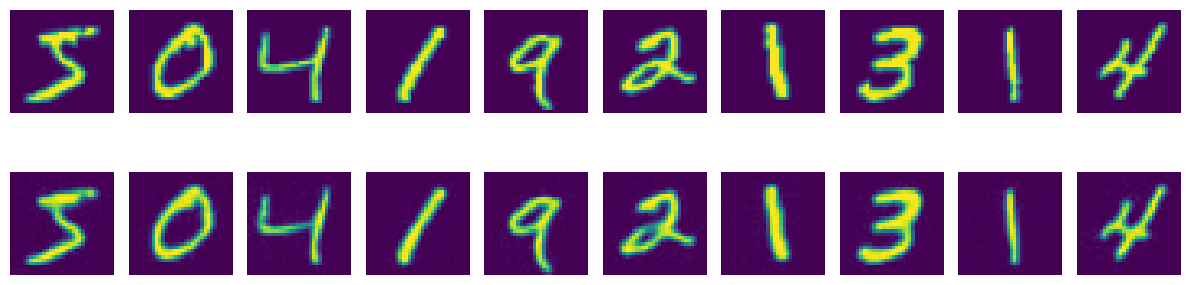

epoch: 13
reconstruction loss=0.002171048644433419
commit loss=0.0012783871514101823
total loss=0.0034494358003139495
perplexity=7.379098063405355



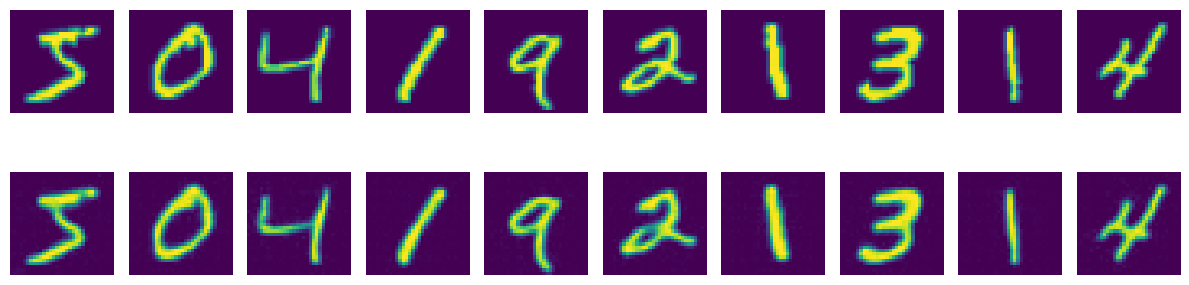

epoch: 14
reconstruction loss=0.002101695363720258
commit loss=0.0013073030089959501
total loss=0.0034089983729024727
perplexity=7.463515265655517



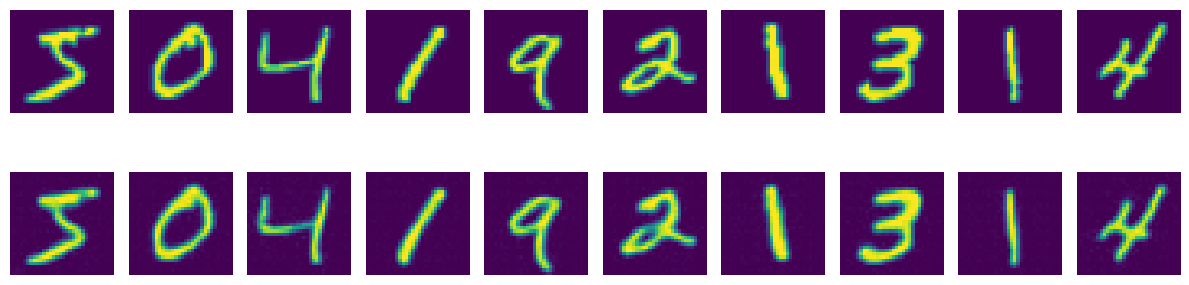

epoch: 15
reconstruction loss=0.002035240887105465
commit loss=0.0013297572288662196
total loss=0.0033649981189519166
perplexity=7.54474238764445



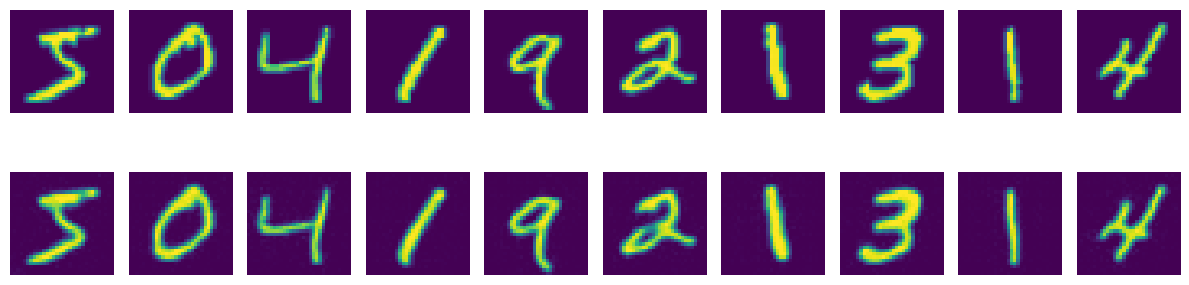

In [9]:
perplexity_list,loss_list,recon_loss_list,commit_loss_list,best_model=Train.train_pipeline(
    init_model,train_loader,EPOCHS,PRINT_EPOC,lr,wd,device,
    mean,std
)

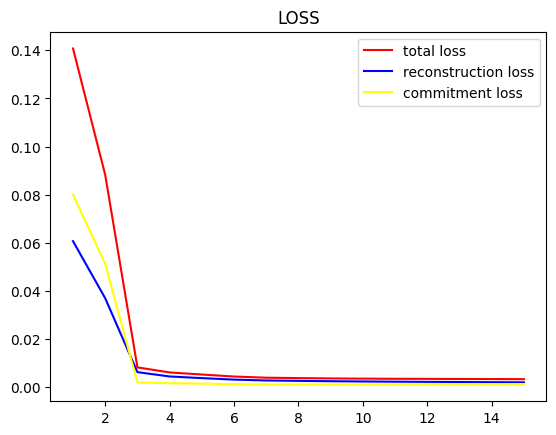

In [10]:
plt.plot(torch.arange(1,EPOCHS+1),loss_list,"red",label="total loss")
plt.plot(torch.arange(1,EPOCHS+1),recon_loss_list,"blue",label="reconstruction loss")
plt.plot(torch.arange(1,EPOCHS+1),commit_loss_list,"yellow",label="commitment loss")

plt.legend()
plt.title("LOSS")
plt.show()

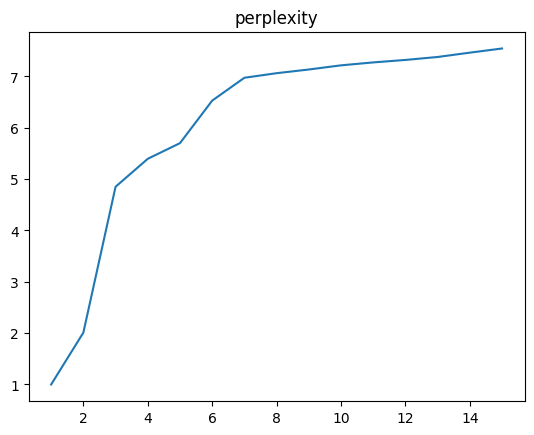

In [11]:
plt.plot(torch.arange(1,EPOCHS+1),perplexity_list)
plt.title("perplexity")
plt.show()

In [12]:
import os

SAVE_DIR = r"..\checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "best_vqvae_mnist.pt")

torch.save({
    "model_state_dict": best_model.state_dict(),
    "loss_list": loss_list,
    "recon_loss_list": recon_loss_list,
    "commit_loss_list": commit_loss_list,
    "perplexity_list": perplexity_list,
    "best_loss": min(loss_list),
    "config": {
        "IN_CHANNELS": IN_CHANNELS,
        "HIDDEN_CHANNELS": HIDDEN_CHANNELS,
        "OUT_CHANNELS": OUT_CHANNELS,
        "RESIDUAL_CHANNELS": RESIDUAL_CHANNELS,
        "RESIDUAL_LAYERS": RESIDUAL_LAYERS,
        "NUM_EMBEDDINGS": NUM_EMBEDDINGS,
        "EMBEDDING_DIM": EMBEDDING_DIM,
        "DECAY": DECAY,
        "COMMIT_COST": COMMIT_COST,
    },
}, SAVE_PATH)

print(f"best model saved to: {SAVE_PATH}")
print(f"best total loss: {min(loss_list):.6f}")

best model saved to: ..\checkpoints\best_vqvae_mnist.pt
best total loss: 0.003365


# 4. 测试集重建

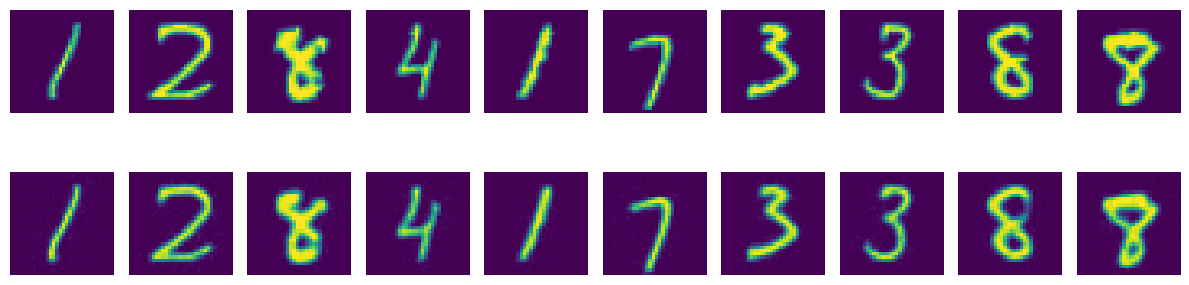

In [15]:
Train.valid(best_model,test_loader,device,mean,std,8)